# CNN Experiment 2 — CIFAR-10 with Data Augmentation

This notebook classifies 32×32 color images into ten CIFAR-10 categories using a compact CNN, batch normalization, dropout, and on-the-fly augmentation.

## 1. Imports and Reproducibility

In [1]:
import os
import random
import warnings

os.environ.setdefault("KERAS_HOME", os.path.abspath(".keras"))
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".mplconfig"))

import numpy as np
import tensorflow as tf

SEED = 42
FAST_RUN = os.getenv("ASSIGNMENT_FAST_RUN", "0") == "1"
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))
print("Fast validation mode:", FAST_RUN)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization, Conv2D, Dense, Dropout, GlobalAveragePooling2D,
    Input, MaxPooling2D, RandomFlip, RandomRotation, RandomTranslation,
)

sns.set_theme(style="whitegrid")

TensorFlow version: 2.20.0
Available GPU devices: []
Fast validation mode: True


## 2. Load and Explore CIFAR-10

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()
if FAST_RUN:
    X_train_full, _, y_train_full, _ = train_test_split(
        X_train_full, y_train_full, train_size=12000, stratify=y_train_full, random_state=SEED
    )
    X_test, y_test = X_test[:3000], y_test[:3000]
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
print("Training images:", X_train_full.shape)
print("Test images:", X_test.shape)
print("Classes:", class_names)

Training images: (12000, 32, 32, 3)
Test images: (3000, 32, 32, 3)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


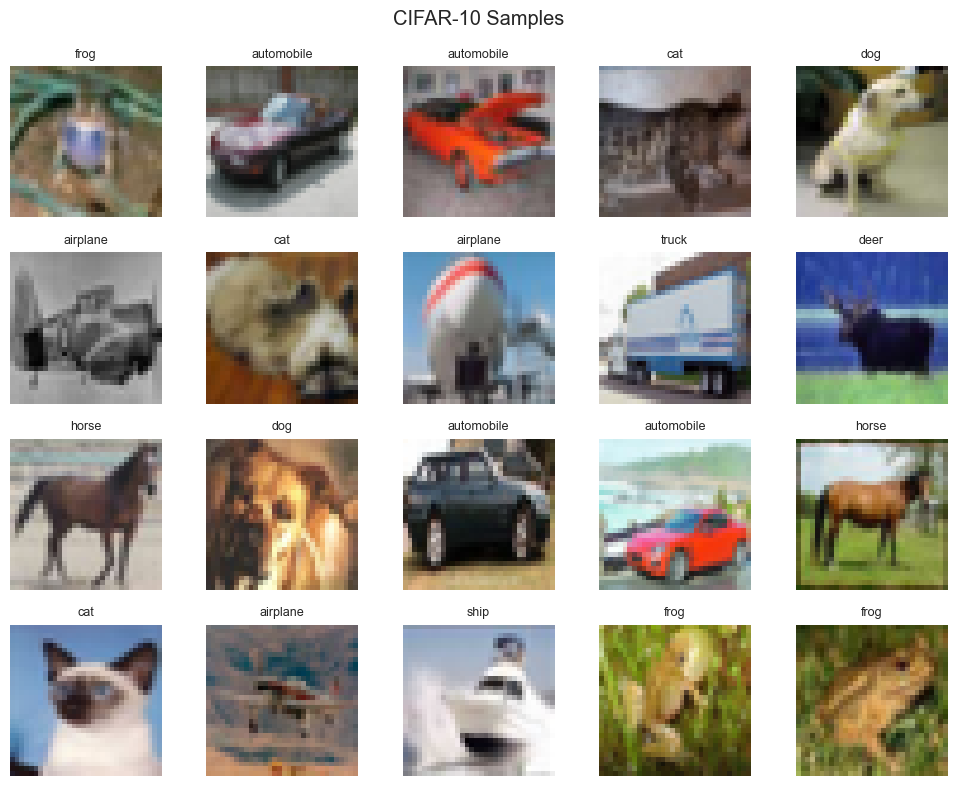

In [3]:
plt.figure(figsize=(10, 8))
for index in range(20):
    plt.subplot(4, 5, index + 1)
    plt.imshow(X_train_full[index])
    plt.title(class_names[y_train_full[index]], fontsize=9)
    plt.axis("off")
plt.suptitle("CIFAR-10 Samples")
plt.tight_layout(); plt.show()

## 3. Preprocessing and Train / Validation / Test Preparation

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10,
    stratify=y_train_full, random_state=SEED
)
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (10800, 32, 32, 3) Validation: (1200, 32, 32, 3) Test: (3000, 32, 32, 3)


## 4. Data Augmentation and CNN Architecture

Small horizontal flips, translations, and rotations create realistic variations during training. Three convolution blocks learn increasingly complex patterns; batch normalization and dropout support stable generalization.

In [5]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomTranslation(0.08, 0.08),
    RandomRotation(0.05),
], name="augmentation")

tf.keras.backend.clear_session()
cifar_model = Sequential([
    Input(shape=(32, 32, 3)),
    data_augmentation,
    Conv2D(32, 3, padding="same", activation="relu"),
    BatchNormalization(momentum=0.9),
    Conv2D(32, 3, padding="same", activation="relu"),
    MaxPooling2D(),
    Dropout(0.20),
    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(momentum=0.9),
    Conv2D(64, 3, padding="same", activation="relu"),
    MaxPooling2D(),
    Dropout(0.25),
    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(momentum=0.9),
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.35),
    Dense(10, activation="softmax"),
], name="cifar10_cnn")
cifar_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cifar_model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,122 (617.66 KB)

 Trainable params: 157,674 (615.91 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Train and Validate

In [6]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]
history = cifar_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=8 if FAST_RUN else 12, batch_size=128, callbacks=callbacks, verbose=2
)

Epoch 1/8


85/85 - 13s - 150ms/step - accuracy: 0.3229 - loss: 1.8158 - val_accuracy: 0.3558 - val_loss: 1.7812 - learning_rate: 1.0000e-03


Epoch 2/8


85/85 - 10s - 117ms/step - accuracy: 0.4312 - loss: 1.5607 - val_accuracy: 0.4233 - val_loss: 1.6598 - learning_rate: 1.0000e-03


Epoch 3/8


...

85/85 - 11s - 124ms/step - accuracy: 0.5567 - loss: 1.2280 - val_accuracy: 0.5142 - val_loss: 1.5490 - learning_rate: 1.0000e-03


Epoch 7/8


85/85 - 10s - 122ms/step - accuracy: 0.5756 - loss: 1.1818 - val_accuracy: 0.5458 - val_loss: 1.3451 - learning_rate: 1.0000e-03


Epoch 8/8


85/85 - 10s - 121ms/step - accuracy: 0.5956 - loss: 1.1374 - val_accuracy: 0.5325 - val_loss: 1.3969 - learning_rate: 1.0000e-03


## 6. Accuracy and Loss Graphs

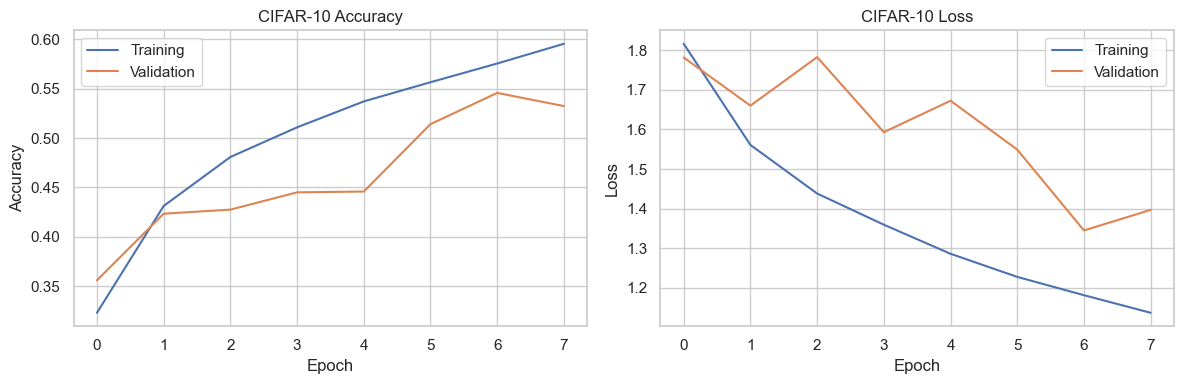

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set(title="CIFAR-10 Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()
axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set(title="CIFAR-10 Loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Test Evaluation

In [8]:
test_loss, test_accuracy = cifar_model.evaluate(X_test, y_test, verbose=0)
probabilities = cifar_model.predict(X_test, verbose=0)
y_pred = probabilities.argmax(axis=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names))

Test loss: 1.4079
Test accuracy: 0.5367
              precision    recall  f1-score   support

    airplane       0.56      0.64      0.60       299
  automobile       0.62      0.88      0.73       287
        bird       0.63      0.24      0.35       318
         cat       0.48      0.14      0.21       295
        deer       0.54      0.20      0.29       299
         dog       0.66      0.33      0.44       290
        frog       0.36      0.93      0.51       307
       horse       0.69      0.56      0.62       286
        ship       0.62      0.82      0.70       316
       truck       0.56      0.62      0.59       303

    accuracy                           0.54      3000
   macro avg       0.57      0.54      0.50      3000
weighted avg       0.57      0.54      0.50      3000



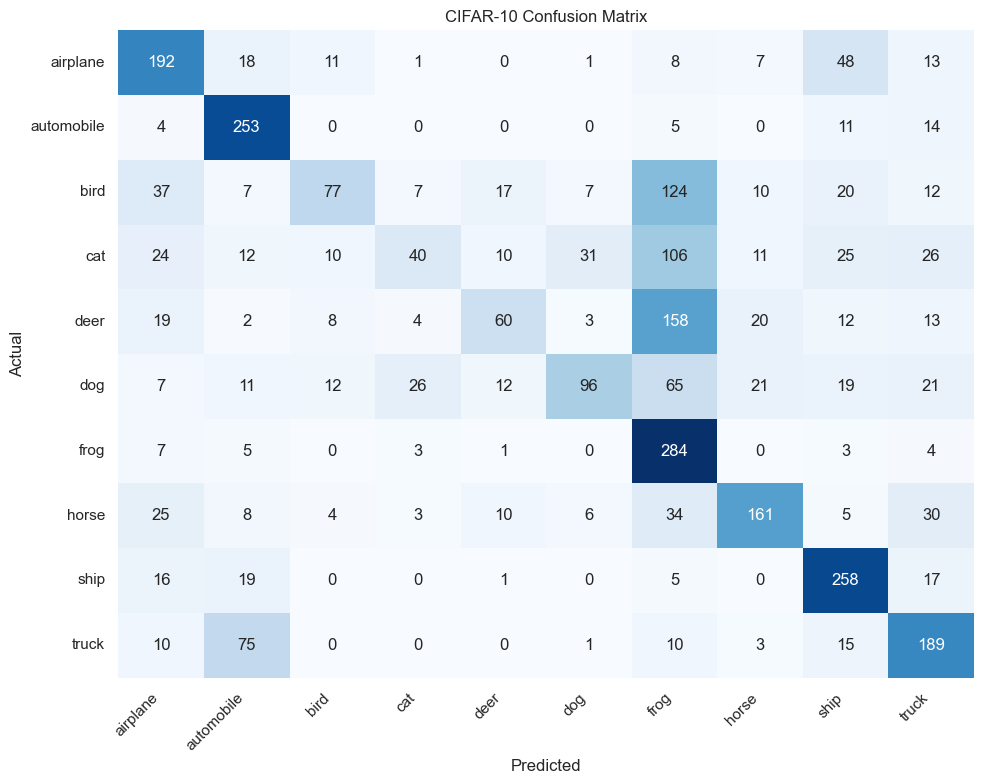

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title("CIFAR-10 Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 8. Sample Predictions

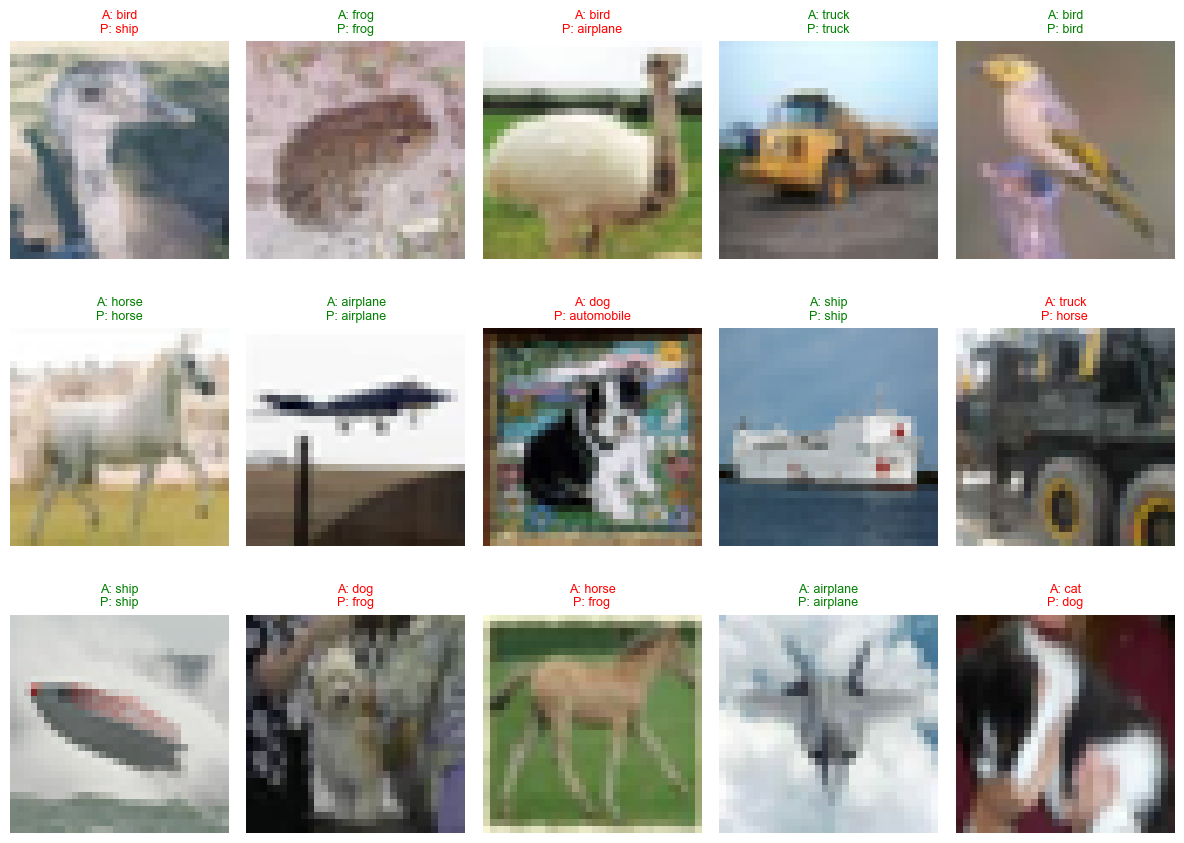

In [10]:
rng = np.random.default_rng(SEED)
indices = rng.choice(len(X_test), size=15, replace=False)
plt.figure(figsize=(12, 9))
for plot_index, image_index in enumerate(indices):
    plt.subplot(3, 5, plot_index + 1)
    plt.imshow(X_test[image_index])
    color = "green" if y_pred[image_index] == y_test[image_index] else "red"
    plt.title(f"A: {class_names[y_test[image_index]]}\nP: {class_names[y_pred[image_index]]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

## 9. Conclusion

This experiment applies the course CNN building blocks to a harder color-image dataset. The augmentation and regularization improve robustness, while the classification report and confusion matrix identify which visually similar classes remain challenging.